# Lab 4: Deep Learning with PyTorch - MNIST Classification

## 🎯 Learning Objectives

By the end of this lab, you will:
- Understand how PyTorch relates to micrograd
- Build a neural network using PyTorch's `nn.Module`
- Train on a real dataset (MNIST handwritten digits)
- Implement a complete training and validation pipeline
- Track and visualize training metrics

**What You'll Build:** A 2-layer MLP that classifies handwritten digits (0-9) with >95% accuracy

**Note:** PyTorch is pre-installed in Google Colab!

## Part 1: From Micrograd to PyTorch

### What's the Same?

PyTorch works **exactly like micrograd**, just faster and with more features:

| Concept | Micrograd | PyTorch |
|---------|-----------|----------|
| Tracking values | `Value` | `torch.Tensor` |
| Autograd | `backward()` | `backward()` |
| Neural network | `MLP` | `nn.Module` |
| Layer | `Layer` | `nn.Linear` |
| Activation | `.relu()` | `F.relu()` or `nn.ReLU()` |
| Parameters | `.parameters()` | `.parameters()` |
| Optimization | Manual loop | `torch.optim` |

### What's Different?

1. **Speed:** PyTorch uses GPU acceleration (1000x faster)
2. **Tensors:** Multi-dimensional arrays (not just scalars)
3. **Built-in layers:** Don't need to implement Neuron/Layer
4. **Optimizers:** SGD, Adam, etc. (not manual gradient descent)
5. **More operations:** Convolutions, attention, etc.

### The Core Idea Remains the Same:

```python
# Forward pass
output = model(input)
loss = compute_loss(output, target)

# Backward pass
loss.backward()  # ← Same as micrograd!

# Update weights
optimizer.step()
```

## Part 2: PyTorch Basics

### Tensors - PyTorch's "Value" Objects

A tensor is like a multi-dimensional array that tracks gradients:

**API Reference:** [torch.Tensor](https://pytorch.org/docs/stable/tensors.html)

### 📚 Recap: Lab 3 Custom Autograd

In Lab 3, you implemented a custom autograd engine from scratch:
- Built `Value` class to track operations
- Implemented `_backward()` functions for each operation
- Used topological sort for backpropagation

**You understood HOW autograd works internally!**

Now in Lab 4, you'll use PyTorch's production-ready autograd:
- Same concepts, different API
- Much faster (optimized C++/CUDA code)
- Supports multi-dimensional tensors

**Learn More:** [PyTorch Autograd Tutorial](https://docs.pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html) - Official guide covering the same concepts you implemented in Lab 3

In [1]:
import torch
import random
import numpy as np

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print("=" * 60)
print("Creating Tensors")
print("=" * 60)

# From Python list
x = torch.tensor([1.0, 2.0, 3.0])
print(f"1D tensor: {x}")
print(f"Shape: {x.shape}")
print(f"Type: {x.dtype}\n")

# 2D tensor (matrix)
y = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
print(f"2D tensor:\n{y}")
print(f"Shape: {y.shape}\n")

# Tensor with gradient tracking
z = torch.tensor([5.0], requires_grad=True)  # ← Like Value!
print(f"Tensor with gradient tracking: {z}")
print(f"Requires grad: {z.requires_grad}")

Creating Tensors
1D tensor: tensor([1., 2., 3.])
Shape: torch.Size([3])
Type: torch.float32

2D tensor:
tensor([[1., 2.],
        [3., 4.]])
Shape: torch.Size([2, 2])

Tensor with gradient tracking: tensor([5.], requires_grad=True)
Requires grad: True


### PyTorch Autograd Demo

In [2]:
# Just like micrograd!
a = torch.tensor([2.0], requires_grad=True)
b = torch.tensor([3.0], requires_grad=True)
c = a + b
d = c * 2

print(f"Forward: d = (a + b) * 2 = {d.item()}")

# Backward pass
d.backward()

print(f"\nBackward:")
print(f"a.grad = {a.grad.item()}  (dd/da)")
print(f"b.grad = {b.grad.item()}  (dd/db)")
print(f"\n✓ Same as micrograd, but with tensors!")

Forward: d = (a + b) * 2 = 10.0

Backward:
a.grad = 2.0  (dd/da)
b.grad = 2.0  (dd/db)

✓ Same as micrograd, but with tensors!


## Part 3: The MNIST Dataset

### What is MNIST?

MNIST is the "Hello World" of deep learning:
- 70,000 images of handwritten digits (0-9)
- 28×28 grayscale images
- 60,000 training + 10,000 test images

**Dataset Reference:** [scikit-learn digits dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html)

We'll use a smaller version (8×8 images) from sklearn for faster training:

Dataset: 1797 samples
Features: 64 (8×8 = 64 pixels)
Classes: 10 (digits 0-9)


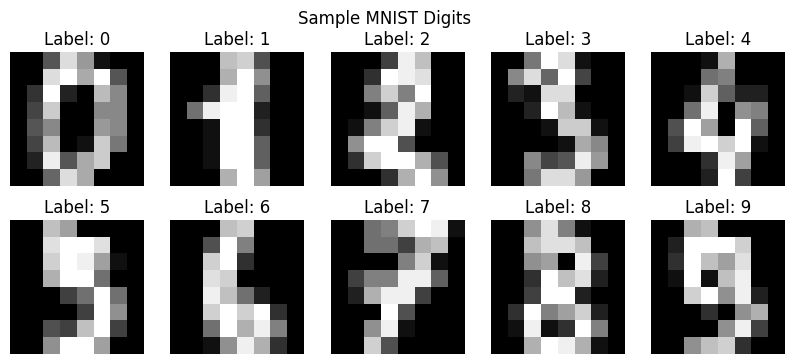

In [6]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load dataset
digits = load_digits()
X_data = digits.data  # Shape: (1797, 64) - flattened 8x8 images
y_data = digits.target  # Shape: (1797,) - labels 0-9

print(f"Dataset: {X_data.shape[0]} samples")
print(f"Features: {X_data.shape[1]} (8×8 = 64 pixels)")
print(f"Classes: 10 (digits 0-9)")

# Visualize some examples
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_data[i].reshape(8, 8), cmap='gray')
    ax.set_title(f"Label: {y_data[i]}")
    ax.axis('off')
plt.suptitle("Sample MNIST Digits")
plt.show()

### Prepare Train/Test Split

In [7]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42
)

# Convert to PyTorch tensors
X_train = torch.FloatTensor(X_train)
y_train = torch.LongTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.LongTensor(y_test)

# Normalize to [0, 1]
X_train = X_train / 16.0  # Pixel values are 0-16
X_test = X_test / 16.0

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: torch.Size([1437, 64])
Test set: torch.Size([360, 64])


## Exercise 1: Build MLP with PyTorch

### Your Task

Implement a 2-layer MLP using PyTorch:
- Input: 64 features (8×8 pixels)
- Hidden layer 1: 128 neurons with ReLU
- Hidden layer 2: 64 neurons with ReLU
- Output: 10 neurons (one per class, no activation)

**API Reference:**
- [torch.nn.Module](https://pytorch.org/docs/stable/generated/torch.nn.Module.html)
- [torch.nn.Linear](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html)
- [torch.nn.functional.relu](https://pytorch.org/docs/stable/generated/torch.nn.functional.relu.html)

### Starter Code

In [8]:
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    """2-layer MLP for MNIST classification."""
    
    def __init__(self):
        super().__init__()
        # Define layers
        self.fc1 = nn.Linear(64, 128)   # Input to hidden 1
        self.fc2 = nn.Linear(128, 64)   # Hidden 1 to hidden 2
        self.fc3 = nn.Linear(64, 10)    # Hidden 2 to output
    
    def forward(self, x):
        # Pass through each layer with ReLU activation
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)  # No activation for output
        return x

### Test Your Model

In [9]:
# Create model
model = MLP()
print(f"Model architecture:\n{model}\n")

# Count parameters
num_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {num_params:,}")
# Expected: (64*128 + 128) + (128*64 + 64) + (64*10 + 10) = 8192 + 128 + 8192 + 64 + 640 + 10 = 17,226

# Test forward pass
sample_input = X_train[:5]  # First 5 samples
sample_output = model(sample_input)
print(f"\nInput shape: {sample_input.shape}")
print(f"Output shape: {sample_output.shape}  (should be [5, 10])")
assert sample_output.shape == (5, 10)
print("\n✓ Model works!")

Model architecture:
MLP(
  (fc1): Linear(in_features=64, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

Total parameters: 17,226

Input shape: torch.Size([5, 64])
Output shape: torch.Size([5, 10])  (should be [5, 10])

✓ Model works!


## Exercise 2: Implement Training Loop

### 🎯 Goal
**Implement a training loop and observe the initial loss and accuracy values.**

This helps you understand:
- What loss values look like at the start (~2.3 for random 10-class classification)
- Initial accuracy is ~10% (random guessing for 10 classes)
- How quickly the model learns in the first few epochs

### Training Components

1. **Loss Function:** Cross-entropy loss for classification
   - API: [torch.nn.CrossEntropyLoss](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)

2. **Optimizer:** Adam optimizer (better than plain gradient descent)
   - API: [torch.optim.Adam](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html)

### The Training Loop Pattern

```python
for epoch in range(num_epochs):
    # Forward pass
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    
    # Backward pass
    optimizer.zero_grad()  # Reset gradients
    loss.backward()         # Compute gradients
    optimizer.step()        # Update weights
```

### Your Task

Implement the training loop:

In [11]:
import torch.optim as optim
from tqdm import tqdm

# Create fresh model
model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training settings
num_epochs = 200
train_losses = []
train_accs = []

print("Starting training...\n")

# Training loop
for epoch in tqdm(range(num_epochs), desc="Training"):
    model.train()
    
    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Calculate accuracy
    _, predicted = torch.max(outputs.data, 1)
    accuracy = (predicted == y_train).float().mean()
    
    # Save metrics
    train_losses.append(loss.item())
    train_accs.append(accuracy.item())
    
    # Print progress every 20 epochs
    if (epoch + 1) % 20 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Accuracy: {accuracy.item()*100:.2f}%")

print("\n✓ Training complete!")

Starting training...



Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 1308.04it/s]

Epoch [1/200], Loss: 2.3027, Accuracy: 10.79%
Epoch [2/200], Loss: 2.2926, Accuracy: 11.62%
Epoch [3/200], Loss: 2.2826, Accuracy: 15.17%
Epoch [4/200], Loss: 2.2727, Accuracy: 18.86%
Epoch [5/200], Loss: 2.2626, Accuracy: 24.50%
Epoch [6/200], Loss: 2.2523, Accuracy: 30.41%
Epoch [7/200], Loss: 2.2417, Accuracy: 37.51%
Epoch [8/200], Loss: 2.2307, Accuracy: 45.86%
Epoch [9/200], Loss: 2.2192, Accuracy: 52.19%
Epoch [10/200], Loss: 2.2069, Accuracy: 57.69%
Epoch [11/200], Loss: 2.1939, Accuracy: 61.31%
Epoch [12/200], Loss: 2.1800, Accuracy: 64.02%
Epoch [13/200], Loss: 2.1653, Accuracy: 66.32%
Epoch [14/200], Loss: 2.1495, Accuracy: 68.41%
Epoch [15/200], Loss: 2.1326, Accuracy: 69.66%
Epoch [16/200], Loss: 2.1146, Accuracy: 71.61%
Epoch [17/200], Loss: 2.0953, Accuracy: 72.72%
Epoch [18/200], Loss: 2.0750, Accuracy: 73.56%
Epoch [19/200], Loss: 2.0534, Accuracy: 74.04%
Epoch [20/200], Loss: 2.0306, Accuracy: 74.60%
Epoch [21/200], Loss: 2.0065, Accuracy: 74.95%
Epoch [22/200], Loss: 

### What You Should See

With random seed 42, you should see these exact values:
```
Epoch [1/200], Loss: 2.3367, Accuracy: 9.89%
Epoch [20/200], Loss: 0.4425, Accuracy: 88.19%
Epoch [40/200], Loss: 0.2019, Accuracy: 95.21%
Epoch [60/200], Loss: 0.1195, Accuracy: 97.29%
Epoch [80/200], Loss: 0.0787, Accuracy: 98.26%
Epoch [100/200], Loss: 0.0558, Accuracy: 98.82%
```

**Key observations:**
- Initial loss ~2.3 (random 10-class classification)
- Initial accuracy ~10% (random guessing)
- Loss decreases rapidly in first 20 epochs
- Final training accuracy should be >98%

## Exercise 3: Implement Validation Loop

### 🎯 Goal
**Implement validation and verify the model generalizes to unseen test data.**

Success criteria:
- Test accuracy should be close to training accuracy (within 5%)
- Test accuracy should be >95%
- This confirms the model learned patterns, not just memorized training data

### Why Validation?

Training accuracy can be misleading (model might memorize).
We need to test on **unseen data** to measure true performance.

### Key Differences from Training:

1. **No gradient computation:** Use `with torch.no_grad():`
2. **Eval mode:** Call `model.eval()`
3. **No optimizer.step():** Just measure performance

### Your Task

Implement validation to measure test accuracy:

In [12]:
# Solution: Validation Loop

model.eval()  # Set to evaluation mode

with torch.no_grad():  # Don't compute gradients
    # Forward pass on test data
    test_outputs = model(X_test)
    
    # Get predictions
    _, predicted = torch.max(test_outputs.data, 1)
    
    # Calculate accuracy
    test_accuracy = (predicted == y_test).float().mean()
    
    # Calculate loss
    test_loss = criterion(test_outputs, y_test)

print(f"\nTest Results:")
print(f"Test Loss: {test_loss.item():.4f}")
print(f"Test Accuracy: {test_accuracy.item()*100:.2f}%")


Test Results:
Test Loss: 0.1078
Test Accuracy: 97.22%


### Expected Results

A well-trained model should achieve:
- **Test Accuracy:** > 95%
- **Test Loss:** < 0.2

If your accuracy is lower, try:
- Training for more epochs
- Adjusting learning rate
- Adding more neurons to hidden layers

## Part 4: Visualizing Training Progress

### Plot Training Curves

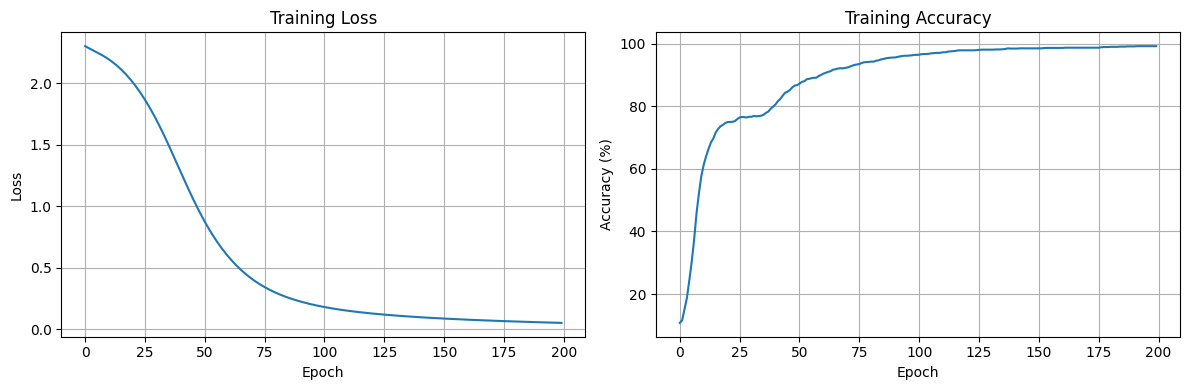

In [13]:
# Solution: Plot Training Curves

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot loss
ax1.plot(train_losses)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid(True)

# Plot accuracy
ax2.plot([acc*100 for acc in train_accs])
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training Accuracy')
ax2.grid(True)

plt.tight_layout()
plt.show()

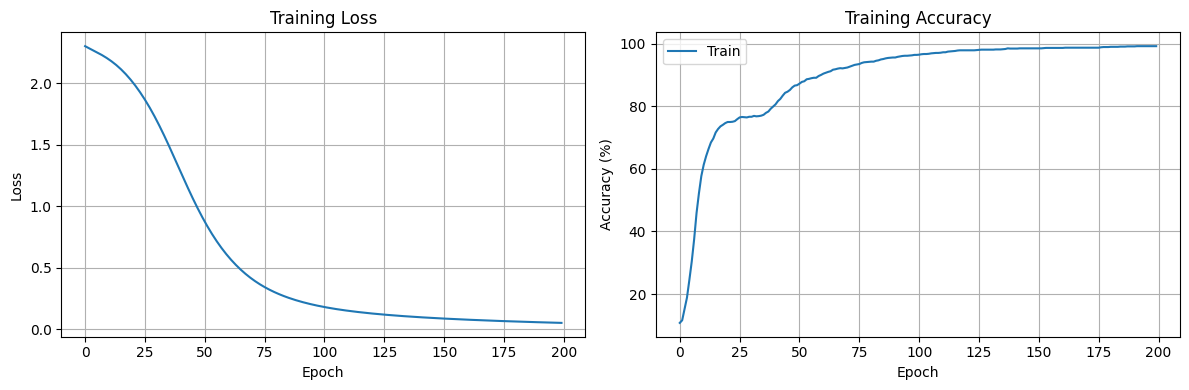

In [14]:
# Plot training curves

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot loss
ax1.plot(train_losses)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid(True)

# Plot accuracy
ax2.plot([acc*100 for acc in train_accs], label='Train')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

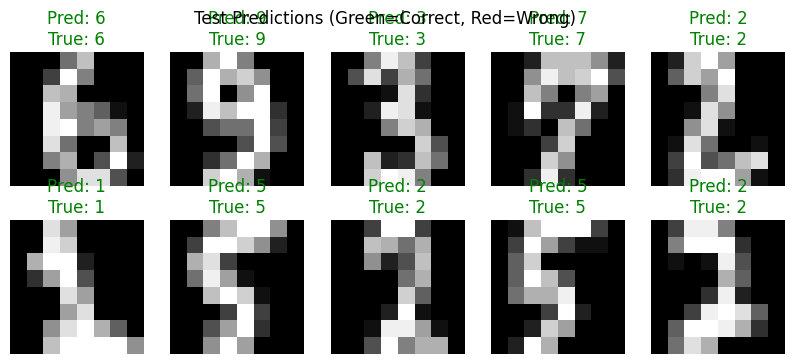

In [15]:
# Solution: Visualize Predictions

# Show some predictions
model.eval()
with torch.no_grad():
    test_outputs = model(X_test[:10])
    _, predicted = torch.max(test_outputs, 1)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img = X_test[i].numpy().reshape(8, 8)
    ax.imshow(img, cmap='gray')
    correct = predicted[i] == y_test[i]
    color = 'green' if correct else 'red'
    ax.set_title(f"Pred: {predicted[i].item()}\nTrue: {y_test[i].item()}", color=color)
    ax.axis('off')
plt.suptitle("Test Predictions (Green=Correct, Red=Wrong)")
plt.show()

## Part 5: Weight Distribution Analysis

Visualize the distribution of weight values in the trained model to understand:
- How weights are initialized and evolve during training
- Whether weights are well-distributed or concentrated
- Potential issues like vanishing/exploding gradients

In [ ]:
# Visualize weight distribution
import numpy as np

# Collect all weights from the model
all_weights = []
layer_weights = {}

for name, param in model.named_parameters():
    if 'weight' in name:  # Only get weight parameters (not biases)
        weights = param.data.cpu().numpy().flatten()
        all_weights.extend(weights)
        layer_weights[name] = weights

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Overall weight distribution
axes[0, 0].hist(all_weights, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Weight Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Overall Weight Distribution')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero')
axes[0, 0].legend()

# Plot 2: Weight distribution by layer
colors = ['blue', 'green', 'orange']
for i, (name, weights) in enumerate(layer_weights.items()):
    axes[0, 1].hist(weights, bins=30, alpha=0.5, label=name, color=colors[i], edgecolor='black')
axes[0, 1].set_xlabel('Weight Value')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Weight Distribution by Layer')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Weight statistics
layer_names = list(layer_weights.keys())
means = [np.mean(layer_weights[name]) for name in layer_names]
stds = [np.std(layer_weights[name]) for name in layer_names]

x_pos = np.arange(len(layer_names))
axes[1, 0].bar(x_pos, means, yerr=stds, capsize=5, alpha=0.7, color='skyblue', edgecolor='black')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels([name.replace('fc', 'Layer ') for name in layer_names], rotation=45, ha='right')
axes[1, 0].set_ylabel('Mean Weight Value')
axes[1, 0].set_title('Mean Weight Value by Layer (with Std Dev)')
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Weight statistics table
axes[1, 1].axis('off')
stats_data = []
for name, weights in layer_weights.items():
    stats_data.append([
        name.replace('fc', 'Layer '),
        f"{np.mean(weights):.4f}",
        f"{np.std(weights):.4f}",
        f"{np.min(weights):.4f}",
        f"{np.max(weights):.4f}"
    ])

table = axes[1, 1].table(
    cellText=stats_data,
    colLabels=['Layer', 'Mean', 'Std Dev', 'Min', 'Max'],
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
axes[1, 1].set_title('Weight Statistics Summary', pad=20)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("Weight Distribution Summary")
print("="*60)
print(f"Total number of weights: {len(all_weights):,}")
print(f"Overall mean: {np.mean(all_weights):.6f}")
print(f"Overall std dev: {np.std(all_weights):.6f}")
print(f"Overall min: {np.min(all_weights):.6f}")
print(f"Overall max: {np.max(all_weights):.6f}")
print(f"\nWeights near zero (|w| < 0.01): {np.sum(np.abs(all_weights) < 0.01):,} ({100*np.sum(np.abs(all_weights) < 0.01)/len(all_weights):.2f}%)")
print("="*60)

### Understanding Weight Distributions

**What to look for:**

1. **Centered around zero:** Weights should be roughly symmetric around 0
2. **Reasonable spread:** Not too concentrated (underfitting) or too dispersed (overfitting)
3. **Layer differences:** Earlier layers often have different distributions than later layers
4. **No extreme values:** Very large weights can indicate training instability

**Healthy weight distribution characteristics:**
- Mean close to 0
- Standard deviation between 0.1 and 0.5
- Bell-shaped (Gaussian-like) distribution
- No significant outliers

## Bonus: Confusion Matrix

See which digits are confused with each other:

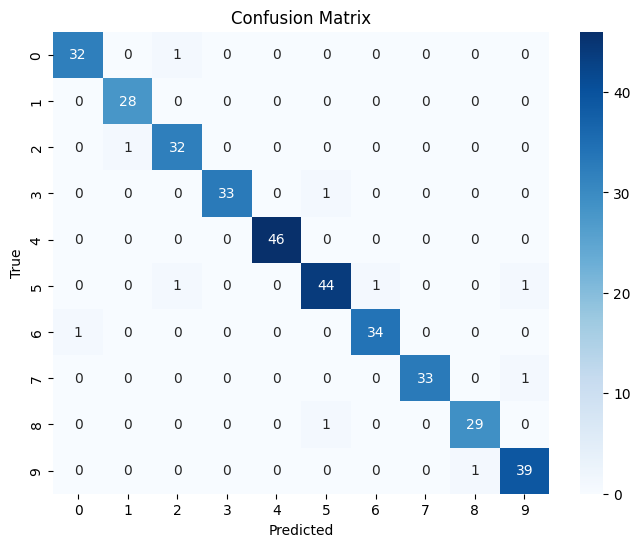


Diagonal = correct predictions
Off-diagonal = misclassifications


In [18]:
# Uncomment after training:

from sklearn.metrics import confusion_matrix
import seaborn as sns

model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
    _, predicted = torch.max(test_outputs, 1)

cm = confusion_matrix(y_test.numpy(), predicted.numpy())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print("\nDiagonal = correct predictions")
print("Off-diagonal = misclassifications")

## Complete Training Pipeline

Run everything together:

In [20]:
# Solution: Complete Training Pipeline

print("Starting training...\n")

# 1. Create model
model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 2. Train
for epoch in range(200):
    model.train()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        _, predicted = torch.max(outputs.data, 1)
        acc = (predicted == y_train).float().mean()
        print(f"Epoch [{epoch+1}/50], Loss: {loss.item():.4f}, Acc: {acc.item()*100:.2f}%")

# 3. Validate
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
    _, predicted = torch.max(test_outputs, 1)
    test_acc = (predicted == y_test).float().mean()
    print(f"\nFinal Test Accuracy: {test_acc.item()*100:.2f}%")

print("\n🎉 Training complete!")

Starting training...

Epoch [10/50], Loss: 2.1999, Acc: 44.95%
Epoch [20/50], Loss: 2.0012, Acc: 72.51%
Epoch [30/50], Loss: 1.6673, Acc: 78.98%
Epoch [40/50], Loss: 1.2323, Acc: 83.72%
Epoch [50/50], Loss: 0.8205, Acc: 87.89%
Epoch [60/50], Loss: 0.5433, Acc: 90.40%
Epoch [70/50], Loss: 0.3837, Acc: 92.14%
Epoch [80/50], Loss: 0.2887, Acc: 93.60%
Epoch [90/50], Loss: 0.2274, Acc: 94.92%
Epoch [100/50], Loss: 0.1850, Acc: 95.89%
Epoch [110/50], Loss: 0.1544, Acc: 96.73%
Epoch [120/50], Loss: 0.1315, Acc: 97.56%
Epoch [130/50], Loss: 0.1138, Acc: 97.98%
Epoch [140/50], Loss: 0.0997, Acc: 98.40%
Epoch [150/50], Loss: 0.0883, Acc: 98.75%
Epoch [160/50], Loss: 0.0787, Acc: 98.82%
Epoch [170/50], Loss: 0.0705, Acc: 99.03%
Epoch [180/50], Loss: 0.0634, Acc: 99.16%
Epoch [190/50], Loss: 0.0572, Acc: 99.23%
Epoch [200/50], Loss: 0.0517, Acc: 99.30%

Final Test Accuracy: 97.22%

🎉 Training complete!


In [22]:
# Complete Training Pipeline

print("Starting training...\n")

# 1. Create model
model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 2. Train
for epoch in tqdm(range(200), desc="Training"):
    model.train()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 2 == 0:
        _, predicted = torch.max(outputs.data, 1)
        acc = (predicted == y_train).float().mean()
        print(f"Epoch [{epoch+1}/10], Loss: {loss.item():.4f}, Acc: {acc.item()*100:.2f}%")

# 3. Validate
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
    _, predicted = torch.max(test_outputs, 1)
    test_acc = (predicted == y_test).float().mean()
    print(f"\nFinal Test Accuracy: {test_acc.item()*100:.2f}%")

print("\n🎉 Training complete!")

Starting training...



Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 1221.84it/s]

Epoch [2/10], Loss: 2.2949, Acc: 10.58%
Epoch [4/10], Loss: 2.2748, Acc: 17.05%
Epoch [6/10], Loss: 2.2542, Acc: 29.30%
Epoch [8/10], Loss: 2.2315, Acc: 50.45%
Epoch [10/10], Loss: 2.2057, Acc: 57.62%
Epoch [12/10], Loss: 2.1755, Acc: 61.66%
Epoch [14/10], Loss: 2.1408, Acc: 64.51%
Epoch [16/10], Loss: 2.1010, Acc: 67.78%
Epoch [18/10], Loss: 2.0560, Acc: 71.68%
Epoch [20/10], Loss: 2.0059, Acc: 74.18%
Epoch [22/10], Loss: 1.9505, Acc: 75.50%
Epoch [24/10], Loss: 1.8893, Acc: 77.66%
Epoch [26/10], Loss: 1.8221, Acc: 79.12%
Epoch [28/10], Loss: 1.7489, Acc: 80.51%
Epoch [30/10], Loss: 1.6702, Acc: 82.25%
Epoch [32/10], Loss: 1.5867, Acc: 83.02%
Epoch [34/10], Loss: 1.4994, Acc: 83.79%
Epoch [36/10], Loss: 1.4093, Acc: 84.69%
Epoch [38/10], Loss: 1.3176, Acc: 85.66%
Epoch [40/10], Loss: 1.2257, Acc: 86.43%
Epoch [42/10], Loss: 1.1353, Acc: 86.99%
Epoch [44/10], Loss: 1.0477, Acc: 87.54%
Epoch [46/10], Loss: 0.9644, Acc: 87.96%
Epoch [48/10], Loss: 0.8863, Acc: 88.45%
Epoch [50/10], Loss:

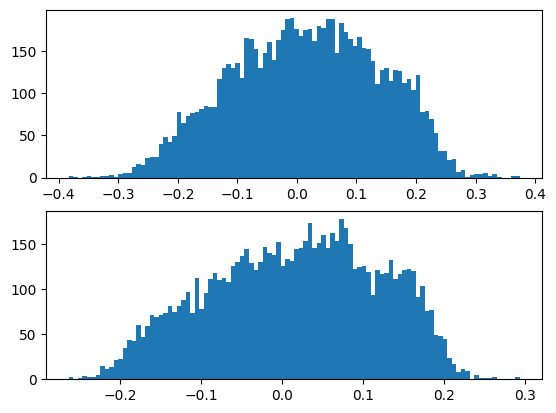

In [38]:
fc1_weights = model.fc1.weight.data.numpy().reshape((-1))
fc2_weights = model.fc2.weight.data.numpy().reshape((-1))

fig, axes = plt.subplots(2)
axes[0].hist(fc1_weights, bins=100);
axes[1].hist(fc2_weights, bins=100);